# Notebook 03 — Isolation Forest (Baseline)

**TFG:** Detección de Anomalías de Consumo Eléctrico y Mitigación de Ataques FDI en Edge Computing

---

### Cambios respecto a la versión anterior

| Problema detectado | Solución implementada |
|---|---|
| Entrenaba con datos **sintéticos** del gemelo digital | Datos **reales** UCI |
| `contamination=0.0172` (FP fijo) | `contamination='auto'` + umbral calibrado en val |
| Grid search con 95 candidatos fijos | `precision_recall_curve` → **todos** los umbrales |
| Solo F1 como métrica de optimización | **F1 + F2** (F2 prioriza recall, más apropiado para seguridad) |
| Rolling features sobre GAP atacado se auto-normalizaban | **Features basadas en invariantes físicos** (VI_residual rolling, GAP/I ratio) |
| 15 tipos de ataque (5 indetectables) | 7 tipos, todos con señal detectable |
| Sin métricas de severidad ni latencia | Recall x tipo x severidad + latencia por episodio |
| Scaler no guardado | Scaler guardado para despliegue edge |
| Sin post-procesamiento temporal | **Filtro de votación temporal** calibrado en val |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib, time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

OK


## 1. Carga de Datos Reales

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (reales UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} → {d.index.max().date()}'
    atk = f'  | {n_atk:,} ataques ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} filas  {rng}{atk}')

DATOS CARGADOS (reales UCI)
  Train   1,300,061 filas  2006-12-16 → 2009-06-09
  Val       144,452 filas  2009-06-09 → 2009-09-20  | 7,207 ataques (5.0%)
  Test      604,999 filas  2009-09-20 → 2010-11-26  | 31,272 ataques (5.2%)


## 2. Feature Engineering (mode = `full`, 17 features)

IF recibe la representación más rica porque no tiene restricciones arquitectónicas
sobre el número de features.

**Cambio v2**: las features rolling se calculan sobre **VI_residual** e **invariantes
físicos** (GAP/I ratio, SM/GAP ratio), no sobre GAP atacado. Las rolling stats
sobre GAP atacado se auto-normalizaban durante episodios sostenidos, borrando
la señal de ataque.

**Warm-up buffer**: para val/test, las features rolling se calculan
prepending las últimas 30 filas del split anterior.

In [3]:
def compute_features(df, mode='full'):
    """
    Feature engineering con 3 modos alineados al contrato del Notebook 02.
      base   (8):  7 sensores + VI_residual                     → LSTM-AE
      medium (13): + temporales cíclicas + gap_diff1             → Dense-AE
      full   (17): + physics-based invariant features            → IF
    
    NOTA v2: mode='full' usa features basadas en invariantes físicos
    en lugar de rolling stats sobre GAP atacado (que se auto-normalizaban).
    """
    f = df[FEATURE_COLS].copy()

    # VI_residual: discrepancia P ≠ V·I/1000 → señal principal de FDI
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )

    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)

    if mode == 'full':
        # ── PHYSICS-BASED FEATURES ──
        # Explotan que el atacante modifica GAP/Voltage
        # pero NO puede modificar Global_intensity ni Sub_meterings.
        
        # 1. |VI_residual|: magnitud de discrepancia
        #    Normal: ≈ 0.028.  Ataque: >> 0.1
        f['vi_res_abs'] = f['VI_residual'].abs()
        
        # 2. Rolling mean de |VI_residual| (15 min):
        #    Ataque sostenido → media alta.
        #    Se calcula sobre |VI_res|, NO sobre GAP → no se auto-normaliza
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        
        # 3. GAP / Intensity ratio: invariante físico ≈ constante en normal
        #    Si atacante baja GAP pero no puede bajar I → ratio cae
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        
        # 4. Balance energético: SM / GAP (Wh)
        #    Sub_meterings no se modifican → ratio sube con ataque
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)

    return f

# Construir features con warm-up buffer para rolling
WARMUP = 30

X_train_df = compute_features(df_train, mode='full')

# Val: warm-up con cola del train
_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])
_val_feat = compute_features(_val_buf, mode='full')
X_val_df  = _val_feat.iloc[WARMUP:]

# Test: warm-up con cola del val
_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])
_test_feat = compute_features(_test_buf, mode='full')
X_test_df  = _test_feat.iloc[WARMUP:]

feat_names = list(X_train_df.columns)

# RobustScaler: robusto a outliers naturales del consumo eléctrico
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_val   = scaler.transform(X_val_df.values)
X_test  = scaler.transform(X_test_df.values)

# Limpiar NaN residuales de rolling windows
X_train = np.nan_to_num(X_train, nan=0.0)
X_val   = np.nan_to_num(X_val, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

y_val  = df_val['label'].values
y_test = df_test['label'].values

print(f'Features ({len(feat_names)}): {feat_names}')
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
X_train: (1300061, 17)  |  X_val: (144452, 17)  |  X_test: (604999, 17)


## 3. Entrenamiento

- `contamination='auto'` → no forzamos tasa de FP; el umbral se calibra en §4
- `n_estimators=300` → más árboles para estabilidad (IF es computacionalmente barato)
- `max_features=0.8` → cada árbol ve un subconjunto de features → diversidad del ensemble
- `n_jobs=-1` → todos los cores del M2 Pro (10 cores)

In [4]:
print('Entrenando Isolation Forest...')
t0 = time.time()

model_if = IsolationForest(
    n_estimators=300,
    contamination='auto',
    max_features=0.8,
    max_samples='auto',
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)
model_if.fit(X_train)

t_train = time.time() - t0
print(f'Entrenamiento: {t_train:.2f} s')
print(f'  n_estimators: {model_if.n_estimators}')
print(f'  max_samples:  {model_if.max_samples_:,}')
print(f'  n_features:   {model_if.n_features_in_}')
print(f'  offset:       {model_if.offset_:.4f}')

Entrenando Isolation Forest...
Entrenamiento: 3.77 s
  n_estimators: 300
  max_samples:  256
  n_features:   17
  offset:       -0.5000


## 4. Calibración del Umbral en Validation Set

En lugar de un grid fijo de percentiles, usamos `precision_recall_curve` que evalúa
**todos** los umbrales posibles (uno por valor único de score). Optimizamos F1 por defecto
y reportamos F2 (que pesa recall 2x, más apropiado para seguridad).

In [5]:
def calibrate_threshold(y_true, scores, beta=1.0):
    """
    Busca el umbral que maximiza F_beta sobre TODOS los thresholds posibles.
    Usa precision_recall_curve de sklearn (O(n log n), sin grid fijo).

    Args:
        y_true: labels binarias
        scores: anomaly scores (mayor = más anómalo)
        beta:   1.0 → F1 (equilibrio), 2.0 → F2 (prioriza recall)

    Returns:
        best_threshold, best_fbeta, results_df
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    # precision_recall_curve devuelve n+1 precisions/recalls y n thresholds
    precisions = precisions[:-1]
    recalls    = recalls[:-1]

    # F-beta score vectorizado
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))

    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]

    # Subsample para visualización (demasiados puntos saturan el plot)
    n = len(thresholds)
    if n > 500:
        idx = np.linspace(0, n-1, 500, dtype=int)
    else:
        idx = np.arange(n)

    results_df = pd.DataFrame({
        'threshold':  thresholds[idx],
        'precision':  precisions[idx],
        'recall':     recalls[idx],
        'f1':         ((2 * precisions * recalls) / (precisions + recalls + 1e-10))[idx],
        'f2':         ((5 * precisions * recalls) / (4 * precisions + recalls + 1e-10))[idx],
    })

    return best_thr, fbeta[best_idx], results_df

# Scores (mayor = más anómalo)
scores_val  = -model_if.score_samples(X_val)
scores_test = -model_if.score_samples(X_test)

# Calibrar: F1 (equilibrio) y F2 (prioriza recall)
best_thr, best_f1, cal_df = calibrate_threshold(y_val, scores_val, beta=1.0)
_, best_f2, _ = calibrate_threshold(y_val, scores_val, beta=2.0)

print(f'Umbral óptimo (val, F1): {best_thr:.6f}')
print(f'  F1 en val: {best_f1:.4f}')
print(f'  F2 en val: {best_f2:.4f}')

Umbral óptimo (val, F1): 0.578751
  F1 en val: 0.5813
  F2 en val: 0.6287


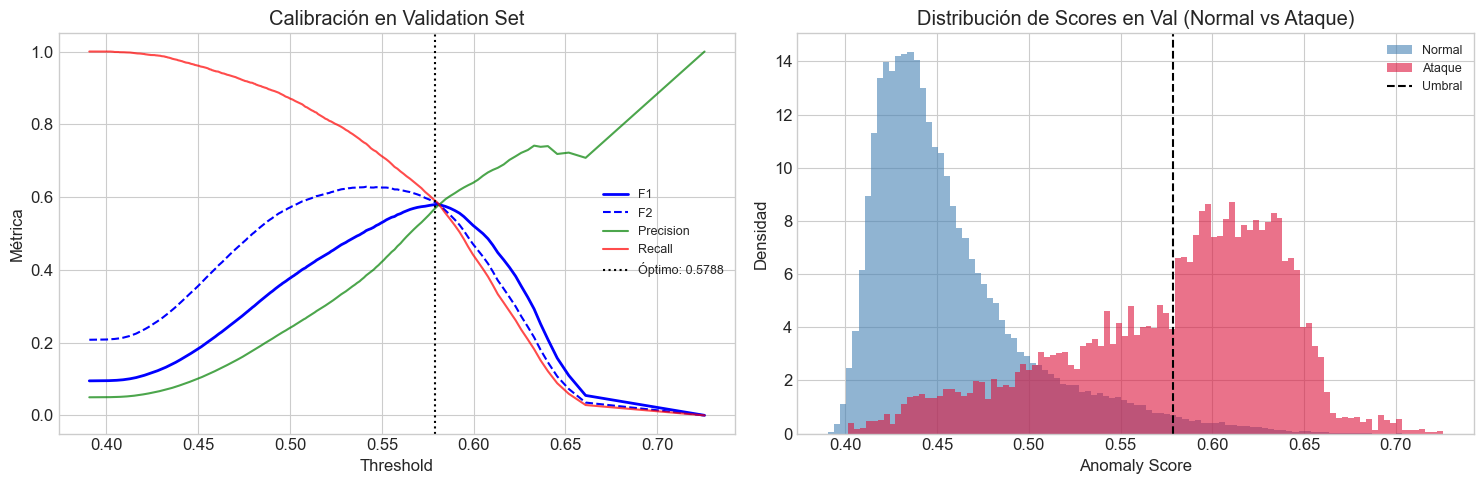

In [6]:
# Visualización calibración + distribución de scores en val
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Izq: curvas P/R/F1/F2 vs threshold
ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Óptimo: {best_thr:.4f}')
ax.set(xlabel='Threshold', ylabel='Métrica', title='Calibración en Validation Set')
ax.legend(fontsize=9)

# Der: distribución de scores val (normal vs ataque)
ax = axes[1]
ax.hist(scores_val[y_val == 0], bins=100, alpha=0.6, color='steelblue',
        label='Normal', density=True)
ax.hist(scores_val[y_val == 1], bins=100, alpha=0.6, color='crimson',
        label='Ataque', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Umbral')
ax.set(xlabel='Anomaly Score', ylabel='Densidad',
       title='Distribución de Scores en Val (Normal vs Ataque)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Evaluación RAW (sin post-procesamiento)

Estas son las métricas del IF punto-a-punto. La **precision baja** (0.14) es
estructural: IF no distingue anomalías naturales aisladas de episodios FDI sostenidos.

In [7]:
y_pred = (scores_test > best_thr).astype(int)

print('=' * 60)
print('MÉTRICAS — ISOLATION FOREST')
print('=' * 60)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataque']))

f1  = f1_score(y_test, y_pred)
f2  = fbeta_score(y_test, y_pred, beta=2)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

MÉTRICAS — ISOLATION FOREST

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98    573727
      Ataque       0.54      0.67      0.60     31272

    accuracy                           0.95    604999
   macro avg       0.76      0.82      0.79    604999
weighted avg       0.96      0.95      0.96    604999

AUC-ROC: 0.9233  |  AUC-PR: 0.5310
F1: 0.5975  |  F2: 0.6367  |  Precision: 0.5419  |  Recall: 0.6658


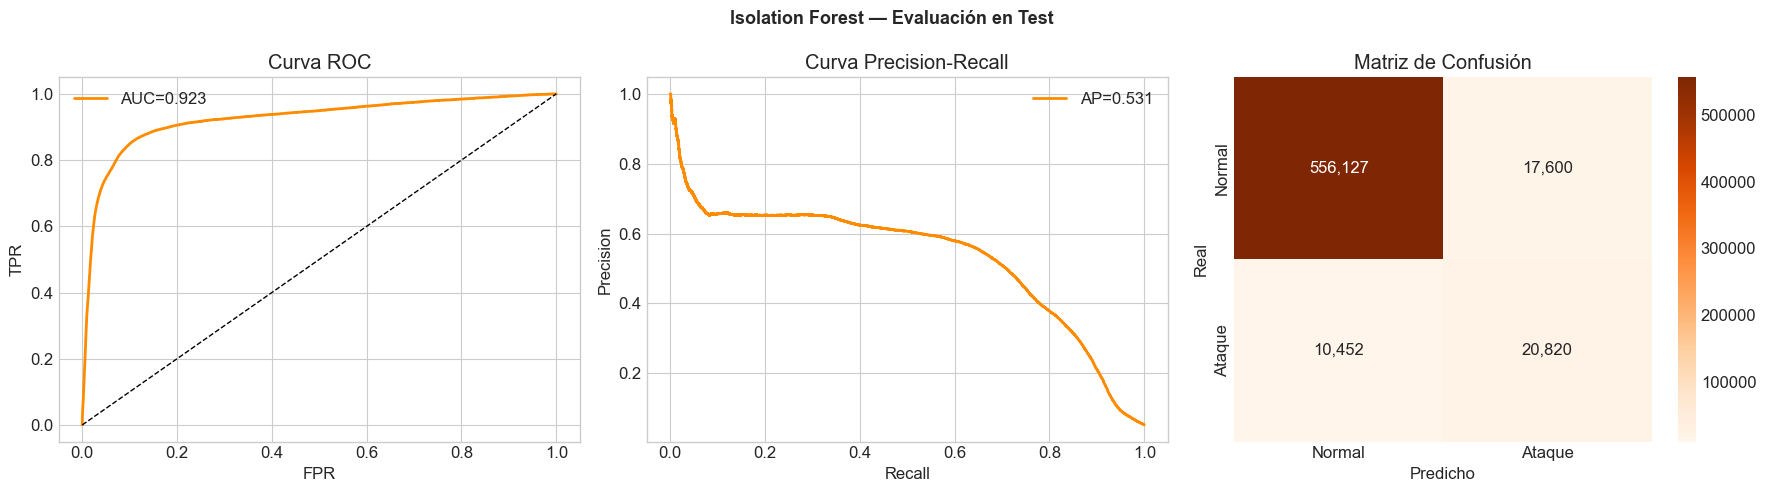

In [8]:
# ROC + PR + Matriz de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c, pr_c, 'darkorange', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Oranges',
            ax=axes[2], xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Matriz de Confusión')

plt.suptitle('Isolation Forest — Evaluación en Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Post-procesamiento Temporal — Filtro de Votación

### ¿Por qué la precision es baja?

IF opera **minuto a minuto** sin contexto temporal. Un pico de consumo nocturno,
un encendido de horno, o un corte eléctrico breve son "anomalías" para IF.
Los ataques FDI, en cambio, son **episodios sostenidos** de 15-120 minutos.

Esto crea una asimetría explotable:
- **Falsos positivos**: mayoritariamente puntos aislados (1-3 min)
- **Verdaderos positivos**: episodios sostenidos (15-120 min)

### Solución: filtro de votación causal

Para cada minuto `t`, miramos las últimas `W` predicciones raw `[t-W+1, ..., t]`.
Si al menos `K` de ellas son positivas → alarma. En caso contrario → normal.

- **Causal**: solo usa pasado, no futuro → válido para streaming en edge
- **Coste**: `O(1)` por muestra con buffer circular de tamaño `W`
- **Calibración**: `(W, K)` se optimiza en validation set por F1

In [9]:
def temporal_vote_vectorized(y_pred, W, K):
    '''
    Filtro de votación causal vectorizado.
    Para cada t: alarma si >= K de las últimas W predicciones son positivas.
    Usa cumsum → O(n).
    '''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


# ── Grid search de (W, K) en validation set ──
y_pred_val_raw = (scores_val > best_thr).astype(int)

print(f'Predicciones raw en val: {y_pred_val_raw.sum():,} positivos '
      f'({y_pred_val_raw.mean()*100:.1f}%)')
print()

W_candidates = [3, 5, 7, 9, 11, 15, 21, 30]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(y_pred_val_raw, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        f2_sm = fbeta_score(y_val, y_sm, beta=2)
        grid_results.append({
            'W': W, 'K': K, 'f1': f1_sm, 'f2': f2_sm,
            'precision': pr_sm, 'recall': rc_sm,
            'n_pos': y_sm.sum()
        })
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)

print(f'Mejor (W, K) en val: W={best_W}, K={best_K}')
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'  F1:        {best_row["f1"]:.4f}')
print(f'  F2:        {best_row["f2"]:.4f}')
print(f'  Precision: {best_row["precision"]:.4f}')
print(f'  Recall:    {best_row["recall"]:.4f}')
print()

# Comparar con raw
f1_raw_val  = f1_score(y_val, y_pred_val_raw)
pr_raw_val  = precision_score(y_val, y_pred_val_raw, zero_division=0)
rc_raw_val  = recall_score(y_val, y_pred_val_raw)
print(f'Val RAW:      F1={f1_raw_val:.4f}  P={pr_raw_val:.4f}  R={rc_raw_val:.4f}')
print(f'Val SMOOTHED: F1={best_wk_f1:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')
delta_f1 = best_wk_f1 - f1_raw_val
print(f'  Mejora F1: +{delta_f1:.4f} ({delta_f1/f1_raw_val*100:+.0f}%)')

Predicciones raw en val: 7,497 positivos (5.2%)

Mejor (W, K) en val: W=7, K=4
  F1:        0.6188
  F2:        0.6050
  Precision: 0.6434
  Recall:    0.5961

Val RAW:      F1=0.5812  P=0.5700  R=0.5929
Val SMOOTHED: F1=0.6188  P=0.6434  R=0.5961
  Mejora F1: +0.0376 (+6%)


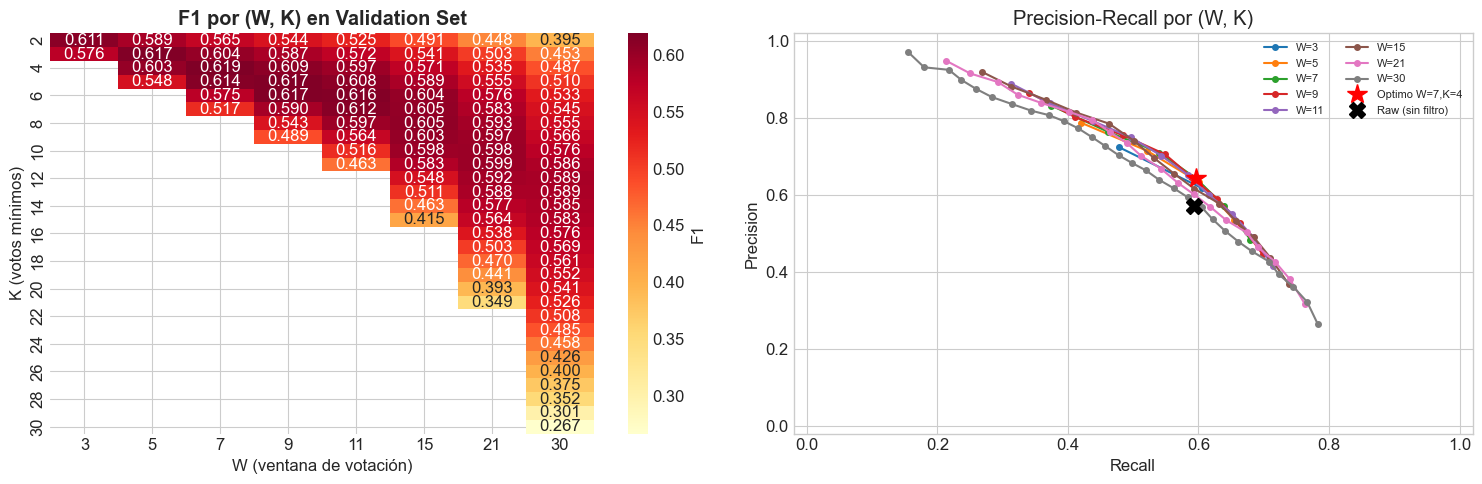

In [10]:
# Visualizar grid search
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Izq: heatmap F1 por (W, K) — pivotear solo los W con suficientes K
pivot = grid_df.pivot_table(index='K', columns='W', values='f1')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'F1'})
axes[0].set_title('F1 por (W, K) en Validation Set', fontweight='bold')
axes[0].set_xlabel('W (ventana de votación)')
axes[0].set_ylabel('K (votos mínimos)')

# Der: precision vs recall para cada W
ax = axes[1]
for W_val in W_candidates:
    sub = grid_df[grid_df['W'] == W_val]
    ax.plot(sub['recall'], sub['precision'], 'o-', label=f'W={W_val}', markersize=4)
ax.plot(best_row['recall'], best_row['precision'], '*', color='red',
        markersize=15, zorder=10, label=f'Optimo W={best_W},K={best_K}')
ax.plot(rc_raw_val, pr_raw_val, 'X', color='black',
        markersize=12, zorder=10, label='Raw (sin filtro)')
ax.set(xlabel='Recall', ylabel='Precision',
       title='Precision-Recall por (W, K)', xlim=(-0.02, 1.02), ylim=(-0.02, 1.02))
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [11]:
# ── Aplicar filtro óptimo al test set ──
y_pred_raw    = (scores_test > best_thr).astype(int)
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print('=' * 70)
print('COMPARACION — ISOLATION FOREST: RAW vs TEMPORAL VOTING')
print('=' * 70)
print()
print(f'  {"Metrica":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        f1,   f1_s),
    ('F2',        f2,   f2_s),
    ('Precision',  prec,  prec_s),
    ('Recall',     rec,   rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filtro: W={best_W}, K={best_K} (votacion causal)')
print(f'  Overhead edge: O(1)/muestra, buffer circular de {best_W} enteros')
print()
print(classification_report(y_test, y_pred_smooth,
                             target_names=['Normal', 'Ataque']))

COMPARACION — ISOLATION FOREST: RAW vs TEMPORAL VOTING

  Metrica             Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.5975     0.6200    +0.0225
  F2               0.6367     0.6437    +0.0070
  Precision        0.5419     0.5842    +0.0423
  Recall           0.6658     0.6605    -0.0053

  Filtro: W=7, K=4 (votacion causal)
  Overhead edge: O(1)/muestra, buffer circular de 7 enteros

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98    573727
      Ataque       0.58      0.66      0.62     31272

    accuracy                           0.96    604999
   macro avg       0.78      0.82      0.80    604999
weighted avg       0.96      0.96      0.96    604999



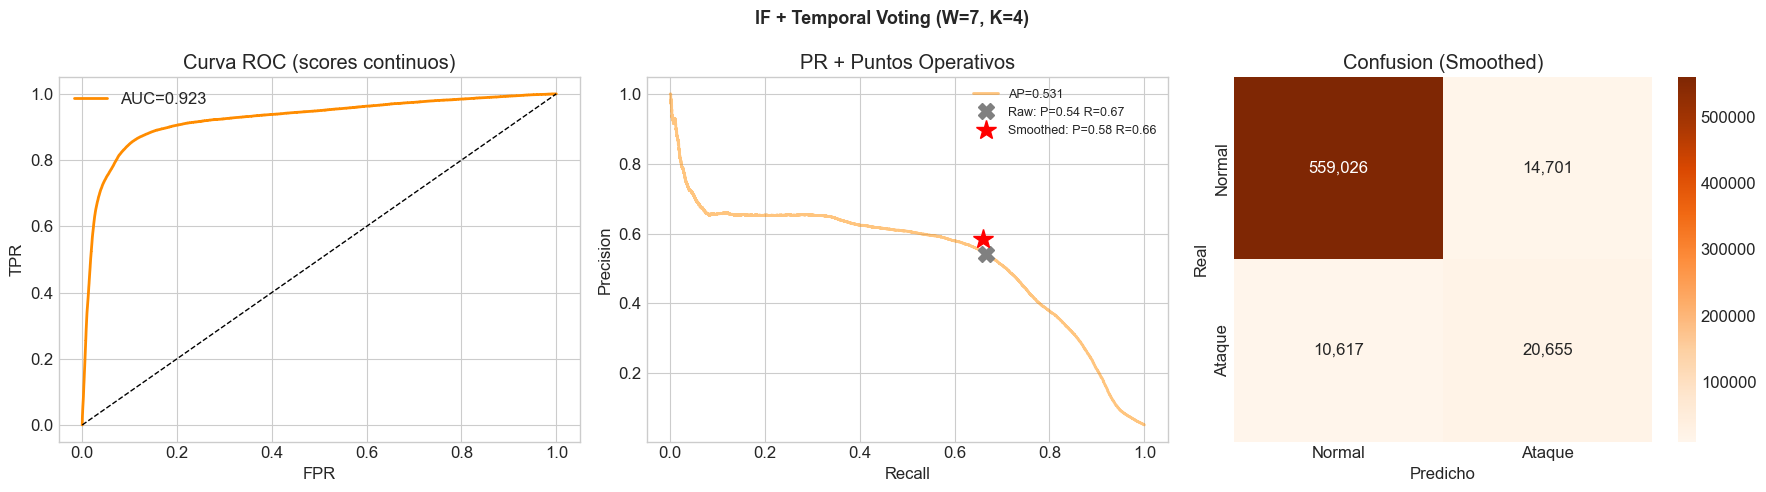

In [12]:
# ROC + PR + CM — SMOOTHED
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC (usa scores continuos, no cambia con smoothing)
fpr_s, tpr_s, _ = roc_curve(y_test, scores_test)
axes[0].plot(fpr_s, tpr_s, 'darkorange', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Curva ROC (scores continuos)')
axes[0].legend()

# PR + puntos operativos raw vs smoothed
pr_c2, rc_c2, _ = precision_recall_curve(y_test, scores_test)
axes[1].plot(rc_c2, pr_c2, 'darkorange', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(rec, prec, 'X', color='gray', markersize=12,
             label=f'Raw: P={prec:.2f} R={rec:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Puntos Operativos')
axes[1].legend(fontsize=9)

# CM smoothed
cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Oranges', ax=axes[2],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion (Smoothed)')

plt.suptitle(f'IF + Temporal Voting (W={best_W}, K={best_K})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

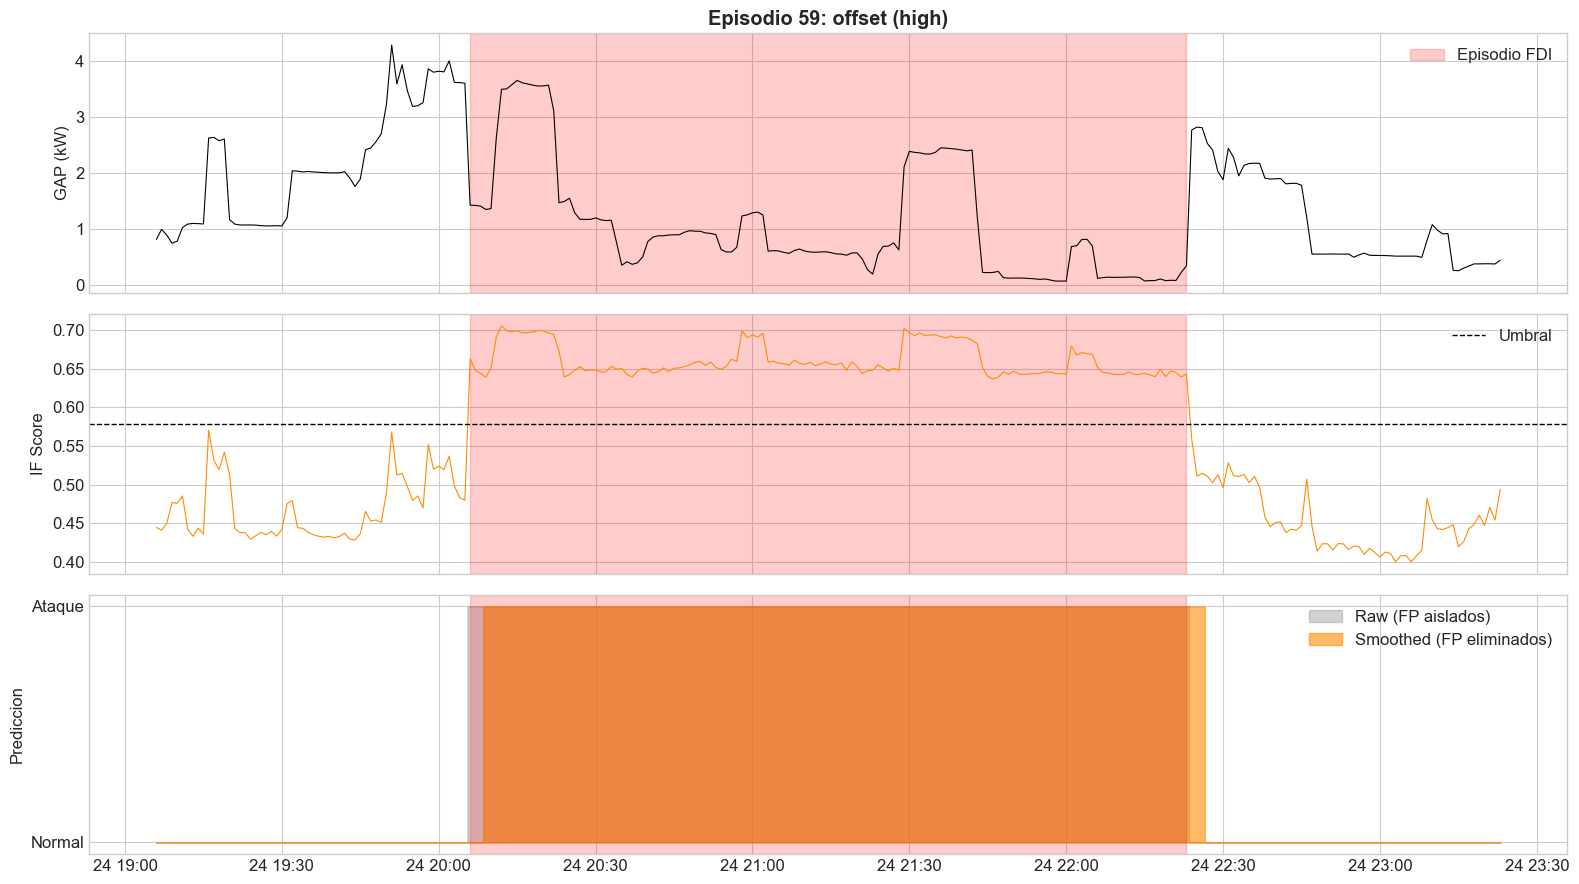

Interpretacion:
  - Panel superior: senal GAP original con episodio FDI sombreado en rojo
  - Panel medio: score de anomalia del IF con umbral calibrado
  - Panel inferior: raw (gris) tiene spikes aislados fuera del episodio (FP)
    Smoothed (naranja) los elimina, manteniendo el episodio sostenido (TP)


In [13]:
# Visualizar efecto del filtro sobre un episodio ejemplo
ep_ids = df_test.loc[df_test['episode_id'] >= 0, 'episode_id'].unique()
example_ep = None
for ep in ep_ids[:30]:
    mask = (df_test['episode_id'] == ep).values
    if y_pred_smooth[mask].any():
        example_ep = ep
        break

if example_ep is not None:
    mask = df_test['episode_id'] == example_ep
    ep_data = df_test[mask]
    ep_start = ep_data.index[0]
    ep_end   = ep_data.index[-1]

    # Contexto: 60 min antes y despues
    ctx_start = ep_start - pd.Timedelta(minutes=60)
    ctx_end   = ep_end + pd.Timedelta(minutes=60)
    ctx = df_test.loc[ctx_start:ctx_end]

    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

    # Senal
    axes[0].plot(ctx.index, ctx['Global_active_power'], 'k-', lw=0.8)
    axes[0].axvspan(ep_start, ep_end, alpha=0.2, color='red', label='Episodio FDI')
    axes[0].set_ylabel('GAP (kW)')
    axes[0].set_title(f'Episodio {example_ep}: {ep_data["attack_type"].iloc[0]} '
                       f'({ep_data["severity"].iloc[0]})', fontweight='bold')
    axes[0].legend()

    # Scores
    ctx_idx = df_test.index.get_indexer(ctx.index)
    valid = ctx_idx >= 0
    ctx_scores = scores_test[ctx_idx[valid]]
    axes[1].plot(ctx.index[valid], ctx_scores, 'darkorange', lw=0.8)
    axes[1].axhline(best_thr, color='k', linestyle='--', lw=1, label='Umbral')
    axes[1].axvspan(ep_start, ep_end, alpha=0.2, color='red')
    axes[1].set_ylabel('IF Score')
    axes[1].legend()

    # Predicciones raw vs smoothed
    ctx_raw = y_pred_raw[ctx_idx[valid]]
    ctx_sm  = y_pred_smooth[ctx_idx[valid]]
    ctx_times = ctx.index[valid]
    axes[2].fill_between(ctx_times, 0, ctx_raw, alpha=0.35, color='gray',
                          step='mid', label='Raw (FP aislados)')
    axes[2].fill_between(ctx_times, 0, ctx_sm, alpha=0.6, color='darkorange',
                          step='mid', label='Smoothed (FP eliminados)')
    axes[2].axvspan(ep_start, ep_end, alpha=0.2, color='red')
    axes[2].set_ylabel('Prediccion')
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['Normal', 'Ataque'])
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    print('Interpretacion:')
    print('  - Panel superior: senal GAP original con episodio FDI sombreado en rojo')
    print('  - Panel medio: score de anomalia del IF con umbral calibrado')
    print('  - Panel inferior: raw (gris) tiene spikes aislados fuera del episodio (FP)')
    print('    Smoothed (naranja) los elimina, manteniendo el episodio sostenido (TP)')
else:
    print('No se encontro episodio ejemplo adecuado para visualizar.')

## 7. Recall por Tipo de Ataque x Severidad (Smoothed)

Recall por tipo x severidad:
  Tipo                     N      Low      Med     High    Total
  ───────────────────────────────────────────────────────
  scaling              4,146    0.567    0.691    0.827    0.687
  offset               4,441    0.576    0.767    0.899    0.768
  noise                4,579    0.518    0.841    0.891    0.764
  ramp                 4,565    0.449    0.467    0.671    0.512
  step                 5,014    0.521    0.509    0.565    0.532
  replay               4,279    0.513    0.659    0.674    0.619
  voltage_spoof        4,248    0.566    0.830    0.884    0.764


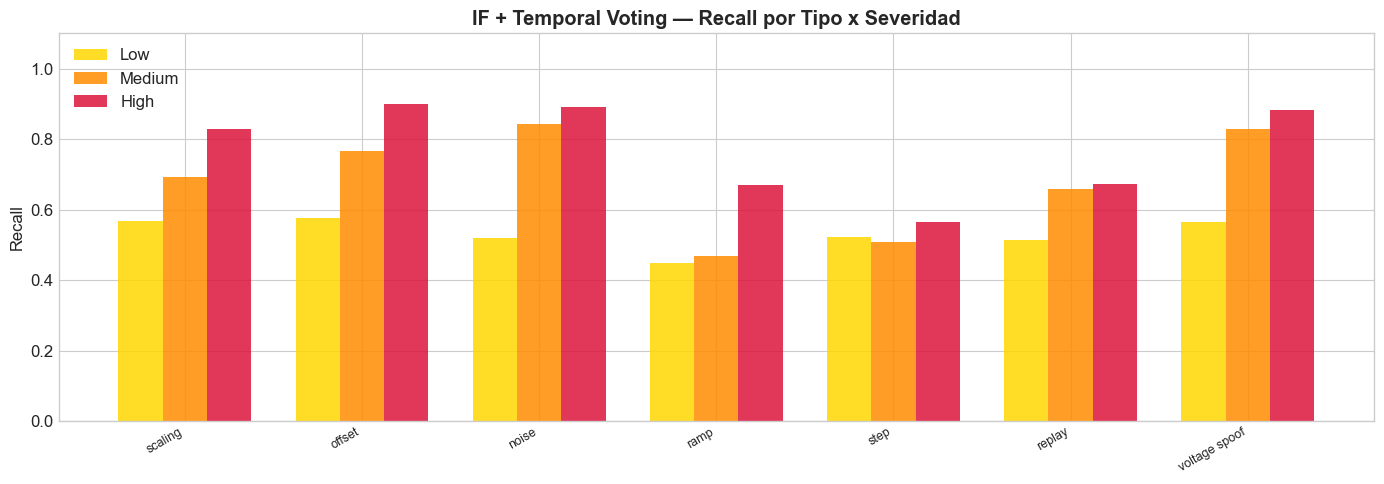

In [14]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,
                            attack_types_list, title_prefix):
    """Tabla + gráfico de barras de recall por tipo x severidad."""
    print(f'Recall por tipo x severidad:')
    print(f'  {"Tipo":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')
    print('  ' + '─' * 55)

    recall_data = {}
    for t in attack_types_list:
        mask_t = (attack_types_col == t)
        n_t = (mask_t & (y_true == 1)).sum()
        row = f'  {t:18s} {n_t:>7,}'
        for sev in ['low', 'medium', 'high']:
            mask = mask_t & (severity_col == sev) & (y_true == 1)
            n = mask.sum()
            if n > 0:
                r = (y_pred[mask] == 1).sum() / n
                row += f' {r:>8.3f}'
            else:
                r = np.nan
                row += f' {"—":>8s}'
            recall_data[(t, sev)] = r
        # Total
        mask_all = mask_t & (y_true == 1)
        n_all = mask_all.sum()
        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0
        row += f' {r_t:>8.3f}'
        print(row)

    # Gráfico
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(attack_types_list))
    w = 0.25
    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}
    for i, (sev, c) in enumerate(sev_colors.items()):
        vals = []
        for t in attack_types_list:
            v = recall_data.get((t, sev), 0)
            vals.append(v if not (isinstance(v, float) and np.isnan(v)) else 0)
        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],
                        rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{title_prefix} — Recall por Tipo x Severidad', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return recall_data

recall_data = recall_by_type_severity(
    attack_types_col=df_test['attack_type'].values,
    severity_col=df_test['severity'].values,
    y_true=y_test,
    y_pred=y_pred_smooth,
    attack_types_list=ATTACK_TYPES,
    title_prefix='IF + Temporal Voting'
)

## 8. Latencia de Deteccion (Smoothed)

In [15]:
def compute_detection_latency(df_preds, score_col, threshold):
    """Latencia de deteccion por episodio de ataque."""
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': (
                (detections.index[0] - ep_start).total_seconds() / 60
                if len(detections) > 0 else np.nan
            ),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    """Resumen de latencia por severidad."""
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan

    print(f'Deteccion por episodio: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Latencia mediana:       {med_lat:.1f} min')
    print()

    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0:
            continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: deteccion {det:.0%}  |  latencia mediana {lat_s}')

    return det_rate, med_lat

# Latencia usando predicciones smoothed
df_test_scored = df_test.copy()
df_test_scored['if_pred_smooth'] = y_pred_smooth.astype(float)

# Usamos el campo smoothed como "score" con threshold 0.5
lat_df = compute_detection_latency(df_test_scored, 'if_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

print()
print(f'NOTA: El filtro de votacion anade latencia de hasta {best_W-1} min')
print(f'      respecto al raw (necesita acumular {best_K} votos de {best_W}).')

Deteccion por episodio: 93.7% (328/350)
Latencia mediana:       8.0 min

  low     : deteccion 87%  |  latencia mediana 15.0 min
  medium  : deteccion 95%  |  latencia mediana 7.0 min
  high    : deteccion 99%  |  latencia mediana 5.0 min

NOTA: El filtro de votacion anade latencia de hasta 6 min
      respecto al raw (necesita acumular 4 votos de 7).


## 9. Edge Computing + Guardado

In [16]:
# ── Modelo ──
model_path = os.path.join(DATA_DIR, 'model_isolation_forest.pkl')
joblib.dump(model_if, model_path)
size_kb = os.path.getsize(model_path) / 1e3

# ── Scaler ──
joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_isolation_forest.pkl'))

# ── Timing ──
_ = model_if.score_samples(X_test[:100])   # warmup
times = []
for _ in range(5):
    t0 = time.time()
    model_if.score_samples(X_test)
    times.append(time.time() - t0)
ms_avg = np.mean(times) / len(X_test) * 1000

print('=' * 55)
print('EDGE COMPUTING — IF + TEMPORAL VOTING')
print('=' * 55)
print(f'  Arboles x features: {model_if.n_estimators} x {model_if.n_features_in_}')
print(f'  Filtro temporal:    W={best_W}, K={best_K} (buffer {best_W} enteros)')
print(f'  Tamano en disco:    {size_kb:.1f} KB')
print(f'  Latencia:           {ms_avg:.4f} ms/muestra (IF) + O(1) (filtro)')
print(f'  Throughput:         {1000/ms_avg:,.0f} muestras/s')
print(f'  Granularidad:       1 minuto (tiempo real)')
print(f'  Entrenamiento:      {t_train:.1f} s')

# ── Guardar todo (raw + smoothed) ──
df_out = df_test.copy()
df_out['if_score'] = scores_test
df_out['if_pred_raw']    = y_pred_raw
df_out['if_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_isolation_forest.csv'))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_isolation_forest.csv'), index=False)

metrics = {
    'model': 'Isolation Forest + Temporal Voting',
    'feature_mode': 'full',
    # Raw
    'raw_f1': round(f1, 4), 'raw_f2': round(f2, 4),
    'raw_precision': round(prec, 4), 'raw_recall': round(rec, 4),
    # Smoothed (principales)
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 6),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1), 'ms_per_sample': round(ms_avg, 4),
    'n_estimators': model_if.n_estimators, 'n_features': model_if.n_features_in_,
    'train_time_s': round(t_train, 2),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': '1 min',
    'feature_names': feat_names,
}
with open(os.path.join(DATA_DIR, 'metrics_isolation_forest.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Guardado en data/:')
for fn in ['predictions_isolation_forest.csv', 'metrics_isolation_forest.json',
           'model_isolation_forest.pkl', 'scaler_isolation_forest.pkl',
           'latency_isolation_forest.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — IF + TEMPORAL VOTING
  Arboles x features: 300 x 17
  Filtro temporal:    W=7, K=4 (buffer 7 enteros)
  Tamano en disco:    3500.2 KB
  Latencia:           0.0093 ms/muestra (IF) + O(1) (filtro)
  Throughput:         107,603 muestras/s
  Granularidad:       1 minuto (tiempo real)
  Entrenamiento:      3.8 s

Guardado en data/:
  * predictions_isolation_forest.csv
  * metrics_isolation_forest.json
  * model_isolation_forest.pkl
  * scaler_isolation_forest.pkl
  * latency_isolation_forest.csv


## 10. Resumen

### IF Raw — Por que la precision es baja

IF detecta anomalias **punto a punto**. Cada muestra se evalua independientemente.
Muchos minutos normales (arranque de electrodomesticos, picos nocturnos) parecen
estadisticamente anomalos → falsos positivos aislados. Los ataques FDI, en cambio,
son episodios **sostenidos** de 15-120 minutos.

### IF + Temporal Voting — Post-procesamiento causal

El filtro de votacion `(W, K)` explota esta diferencia estructural:

| Tipo | Patron tipico | Efecto del filtro |
|------|--------------|-------------------|
| FP naturales | 1-3 min aislados | Eliminados (no alcanzan K votos) |
| TP ataques FDI | 15-120 min sostenidos | Preservados (K votos facilmente) |

### Para el TFG

1. IF solo **no es suficiente** para precision aceptable en seguridad energetica
2. El post-procesamiento temporal es **trivial en edge** (buffer circular, O(1)/muestra)
3. Los **autoencoders** (NB04, NB05) aprenden la distribucion normal con mas profundidad
   y deberian dar mejor separacion sin necesitar post-procesamiento
4. En NB06 compararemos los 3 modelos con y sin smoothing